# Inspect one upright OBB label

Choose a class below, then run all cells to see its rasterized SVG with the OBB overlaid.


In [50]:
from io import BytesIO
from pathlib import Path
import sys

import numpy as np
import yaml
from PIL import Image, ImageDraw
from IPython.display import display

PROJECT_ROOT = next(
    root for root in (Path.cwd(), *Path.cwd().parents)
    if (root / '06_configs' / 'ontology.yaml').exists()
)
SCRIPTS_ROOT = PROJECT_ROOT / '01_scripts'
if str(SCRIPTS_ROOT) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_ROOT))

from generation.core.models import GenerationConfig
from generation.core.metrics import load_symbol_metrics
from generation.core.sampling import load_sampling_config
from generation.registry import COMPOSITE_GENERATORS, GENERATOR_REGISTRY
from labeling import rasterize_and_label_upright_svg


## Configuration

Set `class_key` to one registered `(family, name)` pair. `sampling_overrides` is optional.


In [51]:
class_key = ('instructive', 'jb')
seed = 1234
sampling_overrides = {}
generation_config = GenerationConfig(
    canvas_width_px=150,
    canvas_height_px=150,
    target_visible_px=90.0,
)
with (PROJECT_ROOT / '06_configs' / 'rasterization.yaml').open(encoding='utf-8') as handle:
    rasterization_config = yaml.safe_load(handle)
local_label_supersample_factor = rasterization_config['local_label_supersample_factor']
alpha_threshold = 0
preview_scale = 4


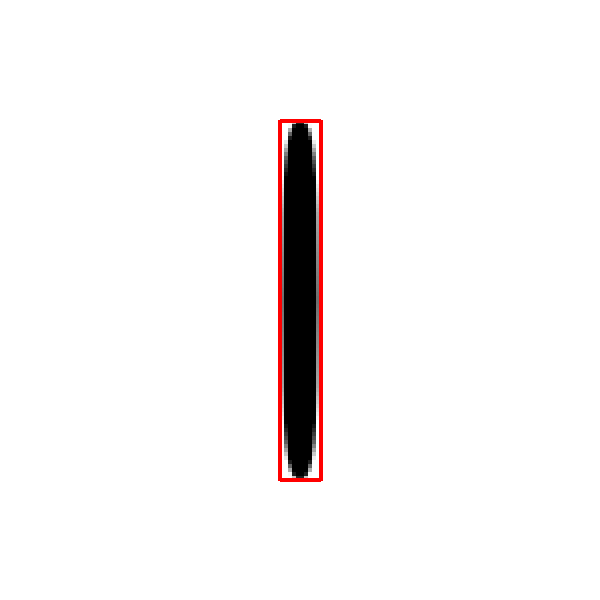

In [52]:
if class_key not in GENERATOR_REGISTRY:
    raise KeyError(f'Unknown class {class_key!r}; choose from {list(GENERATOR_REGISTRY)}')

sampling_config = load_sampling_config(
    ontology_path=PROJECT_ROOT / '06_configs' / 'ontology.yaml',
    sampling_path=PROJECT_ROOT / '06_configs' / 'symbol_sampling.yaml',
)
symbol_metrics = load_symbol_metrics(
    PROJECT_ROOT / '06_configs' / 'symbol_metrics.yaml', sampling_config.class_keys,
)
family, name = class_key
rng = np.random.default_rng(seed)
sample = sampling_config.sample(
    family, name, rng, seed=seed, overrides=sampling_overrides,
)
generator_input = (
    sampling_config.realize_components(family, name, sample, rng)
    if class_key in COMPOSITE_GENERATORS else sample
)
generated = GENERATOR_REGISTRY[class_key](
    sampling_config.resolve(family, name), generator_input,
    symbol_metrics.config_for(class_key, generation_config),
)
png_bytes = rasterize_and_label_upright_svg(
    generated,
    supersample_factor=local_label_supersample_factor,
    alpha_threshold=alpha_threshold,
)

with Image.open(BytesIO(png_bytes)) as png:
    symbol = png.convert('RGBA')
white = Image.new('RGBA', symbol.size, 'white')
white.alpha_composite(symbol)
overlay = white.convert('RGB').resize(
    (symbol.width * preview_scale, symbol.height * preview_scale),
    Image.Resampling.NEAREST,
)
points = [tuple((corner * preview_scale).tolist()) for corner in generated.obb_pixels]
ImageDraw.Draw(overlay).line(
    points + [points[0]], fill='red', width=max(2, preview_scale),
)
display(overlay)
